In [ ]:
from pathlib import Path
from collections import defaultdict
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import torch, timm
import re
import shutil
import torchvision.transforms as T
from sklearn.metrics.pairwise import cosine_similarity
import seaborn as sns
import numpy as np

In [26]:
SOURCE_DIR = Path("../data/raw/Preston Montford 2026")

print(f"Gallery images: {len(list(SOURCE_DIR.iterdir()))}")

filenames = sorted(f.name for f in SOURCE_DIR.iterdir() if f.suffix.lower() in {".jpg", ".jpeg", ".png"})
labels = [id_pattern.search(f).group(1) for f in filenames]

Gallery images: 33


In [27]:
labels

['GCN001',
 'GCN001',
 'GCN001',
 'GCN002',
 'GCN002',
 'GCN002',
 'GCN003',
 'GCN003',
 'GCN003',
 'GCN004',
 'GCN004',
 'GCN004',
 'GCN005',
 'GCN005',
 'GCN006',
 'GCN006',
 'GCN006',
 'GCN007',
 'GCN007',
 'GCN007',
 'GCN008',
 'GCN008',
 'GCN011',
 'GCN011',
 'GCN011',
 'GCN012',
 'GCN012',
 'GCN009',
 'GCN009',
 'GCN009',
 'GCN010',
 'GCN010',
 'GCN010']

In [21]:
model = timm.create_model(
    "hf-hub:BVRA/MegaDescriptor-L-384",
    pretrained=True
).eval()

tfm = T.Compose([
    T.Resize((384, 384)),
    T.ToTensor(),
    T.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225))
])

def embed(img_file):
    img = Image.open(img_file).convert("RGB")
    with torch.no_grad():
        return model(tfm(img).unsqueeze(0)).squeeze().numpy()

# ----- embeddings -----

gallery_ids = list(SOURCE_DIR.iterdir())
gallery_emb = np.vstack([embed(f) for f in gallery_ids])

In [11]:
gallery_emb.shape

(33, 1536)

In [22]:
gallery_ids

[WindowsPath('../data/raw/Preston Montford 2026/PM-P02-GCN001-20260505-AM-001.jpg'),
 WindowsPath('../data/raw/Preston Montford 2026/PM-P02-GCN001-20260505-AM-002.jpg'),
 WindowsPath('../data/raw/Preston Montford 2026/PM-P02-GCN001-20260505-AM-003.jpg'),
 WindowsPath('../data/raw/Preston Montford 2026/PM-P02-GCN002-20260505-AM-001.jpg'),
 WindowsPath('../data/raw/Preston Montford 2026/PM-P02-GCN002-20260505-AM-002.jpg'),
 WindowsPath('../data/raw/Preston Montford 2026/PM-P02-GCN002-20260505-AM-003.jpg'),
 WindowsPath('../data/raw/Preston Montford 2026/PM-P02-GCN003-20260505-AM-001.jpg'),
 WindowsPath('../data/raw/Preston Montford 2026/PM-P02-GCN003-20260505-AM-002.jpg'),
 WindowsPath('../data/raw/Preston Montford 2026/PM-P02-GCN003-20260505-AM-003.jpg'),
 WindowsPath('../data/raw/Preston Montford 2026/PM-P02-GCN004-20260506-PM-001.jpg'),
 WindowsPath('../data/raw/Preston Montford 2026/PM-P02-GCN004-20260506-PM-002.jpg'),
 WindowsPath('../data/raw/Preston Montford 2026/PM-P02-GCN004-202

In [23]:
# ----- similarity matrix -----

sim = cosine_similarity(gallery_emb, gallery_emb)
print("Similarity matrix shape:", sim.shape)

Similarity matrix shape: (33, 33)


In [24]:
import re
import numpy as np

id_pattern = re.compile(r"(GCN\d+)")

# filenames should be in the same order as rows/cols of the similarity matrix
animal_ids = np.array([id_pattern.search(f).group(1) for f in filenames])

# mask[i, j] = True where animal i == animal j
same_animal_mask = animal_ids[:, None] == animal_ids[None, :]

sim[same_animal_mask] = 0

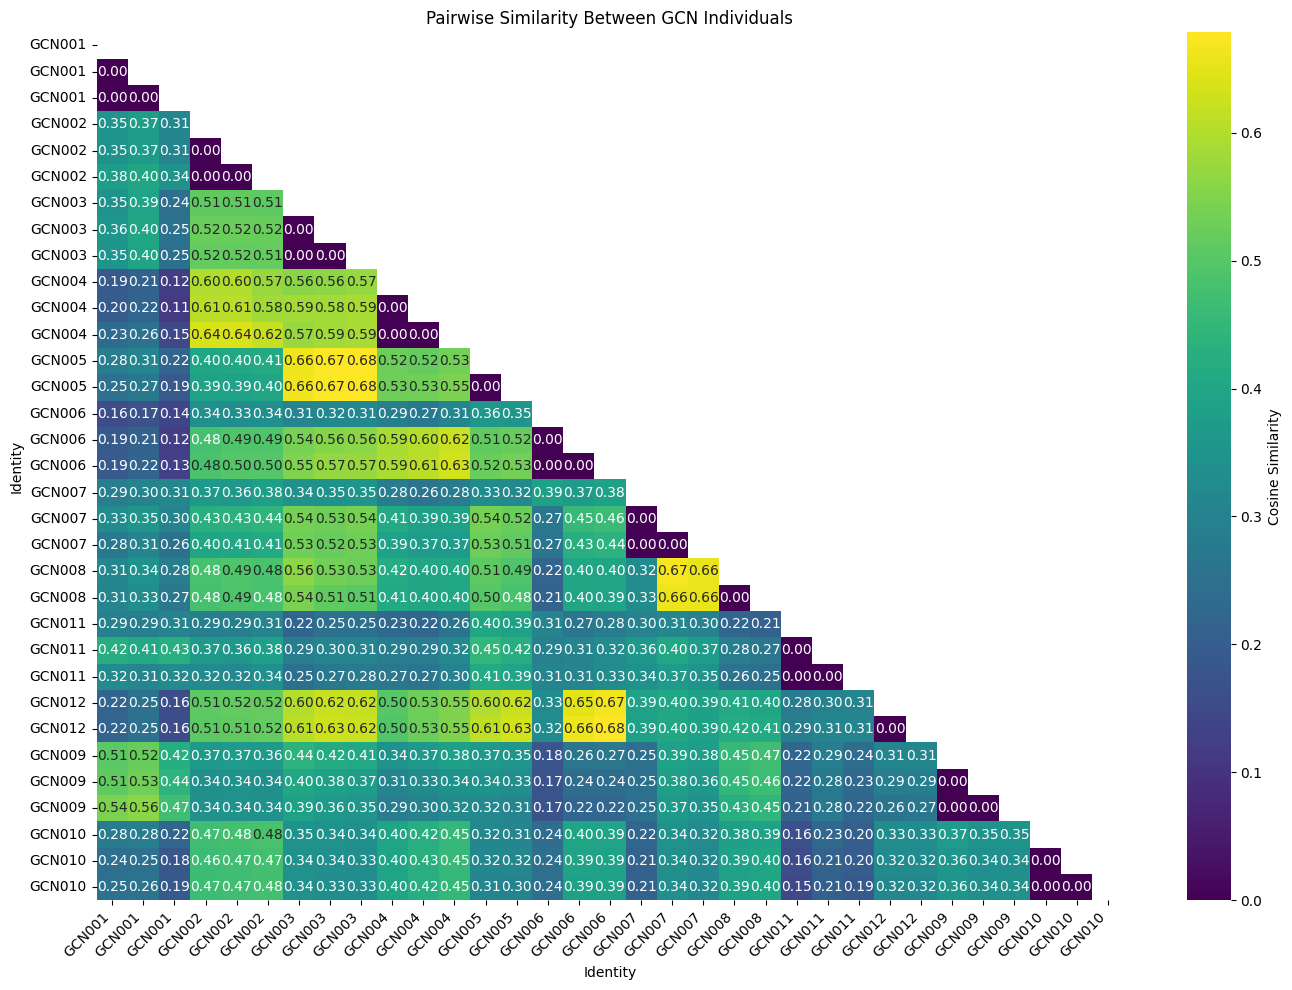

In [29]:


plt.figure(figsize=(14, 10))

mask = np.triu(np.ones_like(sim, dtype=bool), k=0)

sns.heatmap(
    sim,
    mask=mask,
    cmap="viridis",
    annot=True,
    fmt=".2f",
    xticklabels=labels,
    yticklabels=labels,
    cbar_kws={"label": "Cosine Similarity"}
)

plt.title("Pairwise Similarity Between GCN Individuals")
plt.xlabel("Identity")
plt.ylabel("Identity")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
sim_no_diag = sim.copy()
np.fill_diagonal(sim_no_diag, 0)
pred_idx = sim_no_diag.argmax(axis=1)
pred_ids = labels[i] for i in pred_idx

In [41]:
import numpy as np

pred_ids = np.array(pred_ids)
pred_ids[[25,26]]

array(['GCN006', 'GCN006'], dtype='<U6')